<a class="anchor" id="0"></a>
# **Decision Tree Classifier and Naive Bayes with Python**

In [40]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv('https://raw.githubusercontent.com/royhandaus/data_mining_royhan/main/synthetic_coffee_health.csv')
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


mengidentifikasi class labelnya yaitu health issue agar ditaruh ke kolom paling kanan

In [42]:
col = df.pop("Health_Issues")
df["Health_Issues"] = col
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption,Health_Issues
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,NaN
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,NaN
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,Mild
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Mild
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Mild


### View summary of dataset

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Occupation               10000 non-null  object 
 13  Smoking                  10000 non-null  int64  
 14  Alcohol_Consumption    

Mengubah data NaN pada helath issue menjadi None agar tidak ada yang kosong datanya

In [44]:
df["Health_Issues"] = df["Health_Issues"].fillna("None")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Occupation               10000 non-null  object 
 13  Smoking                  10000 non-null  int64  
 14  Alcohol_Consumption    

Drop kolom ID karena tidak dibutuhkan dalam target klasifikasinya

In [45]:
# Drop kolom ID
df = df.drop(columns=["ID"])
df.head()


,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption,Health_Issues
0,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,None
1,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,None
2,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,Mild
3,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Mild
4,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Mild


### Frequency distribution of values in variables

Now, I will check the frequency counts of categorical variables.

In [46]:
# rename columns
col_names = ['age', 'gender', 'country', 'daily_coffee_intake', 'caffeine_lavel_mg', 'sleep_duration_hrs','sleep_quality', 'BMI', 'heart_rate', 'stress_level', 'physical_activity', 'occupation', 'smoking','alcohol_consumption','Health_Issues']
df.columns = col_names
df.head()

,age,gender,country,daily_coffee_intake,caffeine_lavel_mg,sleep_duration_hrs,sleep_quality,BMI,heart_rate,stress_level,physical_activity,occupation,smoking,alcohol_consumption,Health_Issues
0,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0,None
1,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0,None
2,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0,Mild
3,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0,Mild
4,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1,Mild


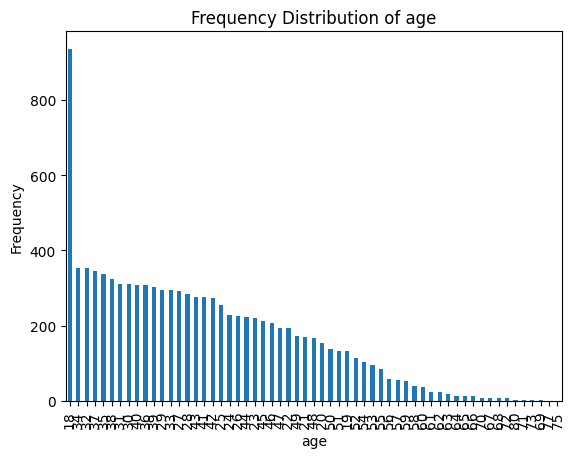

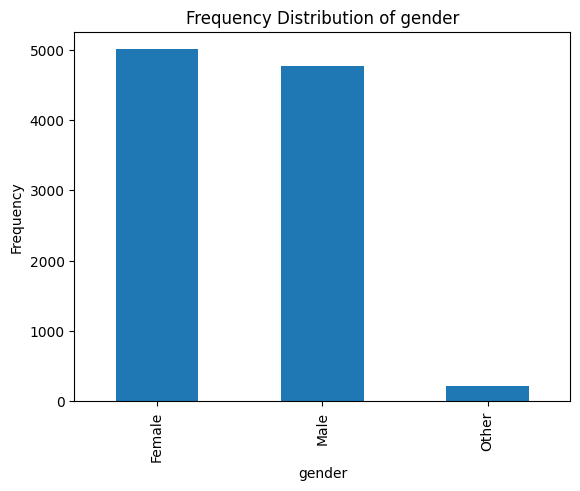

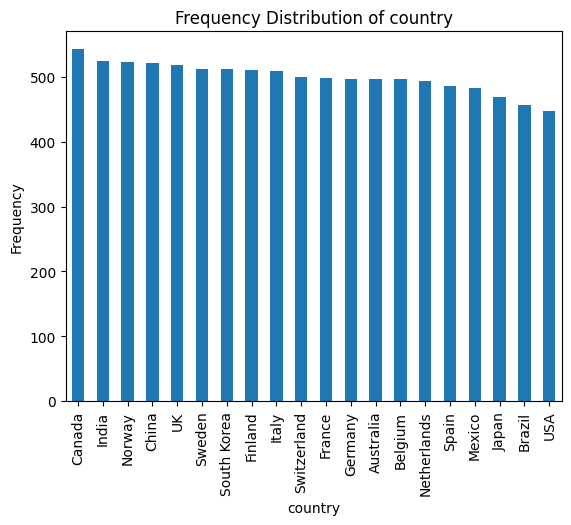

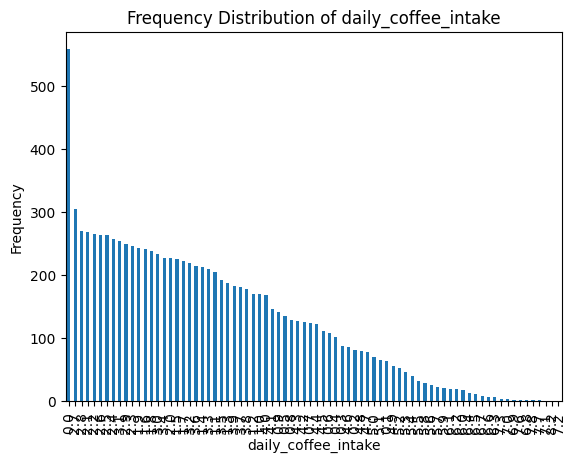

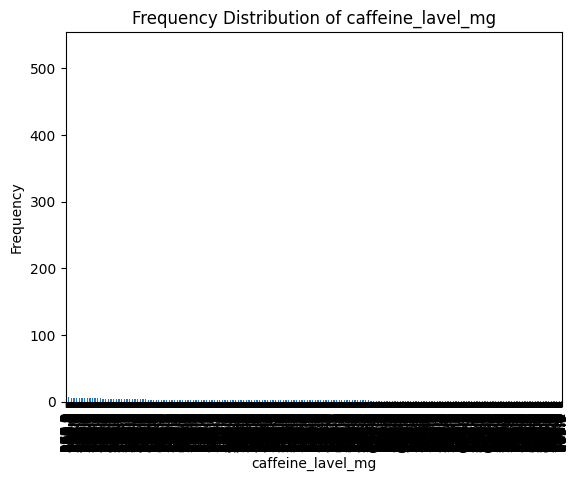

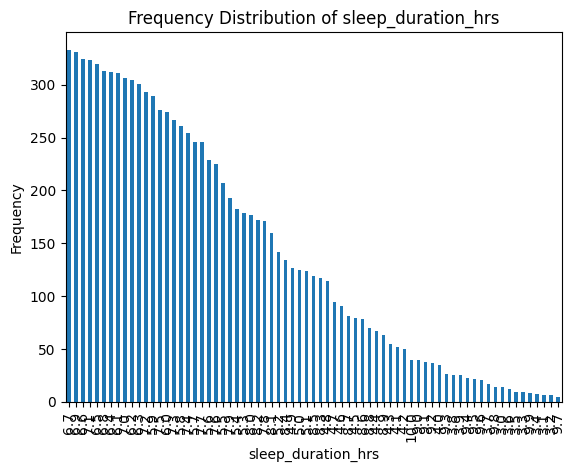

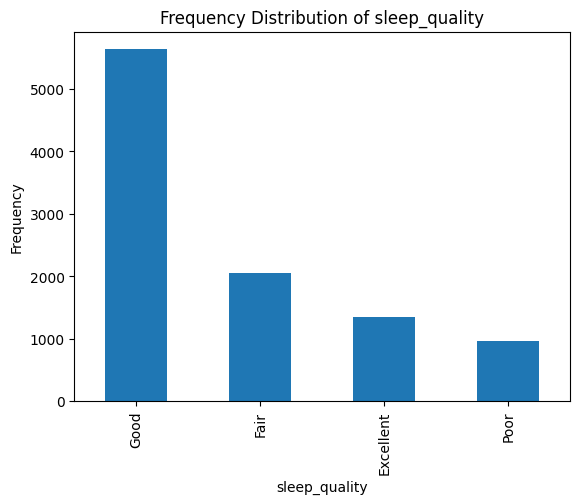

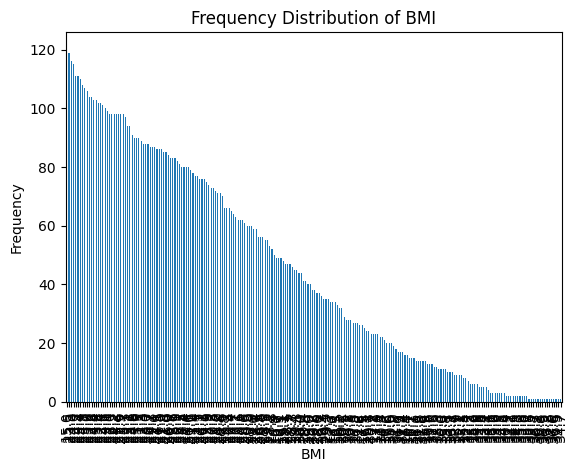

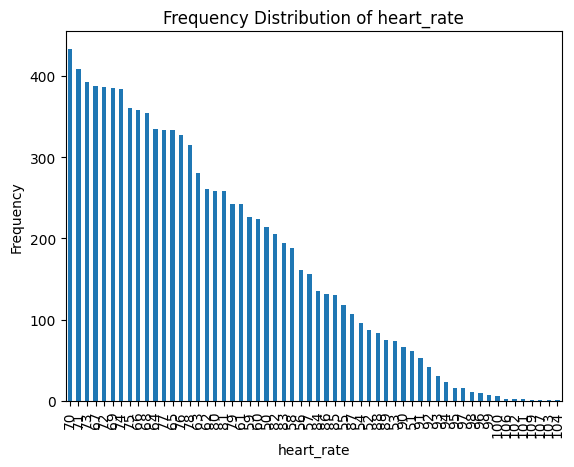

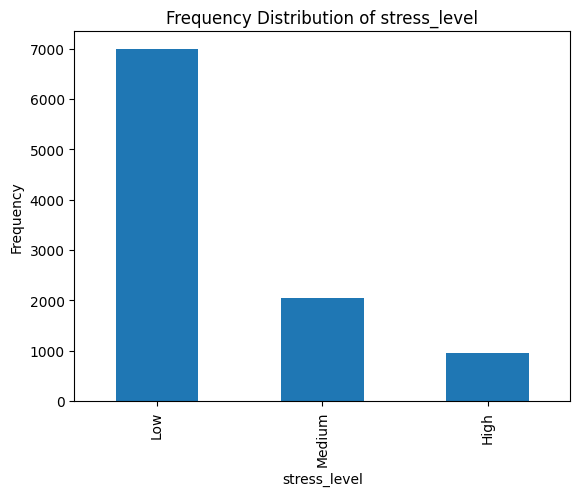

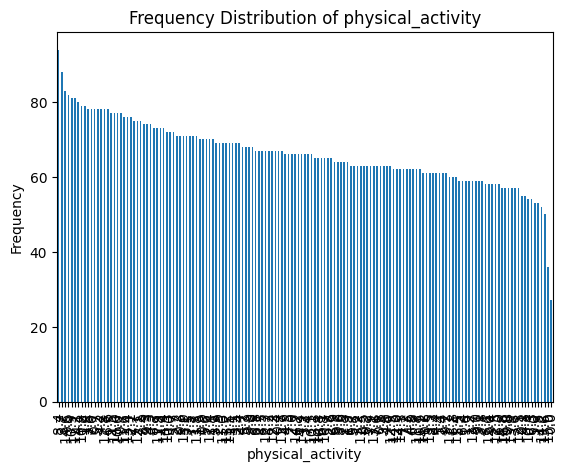

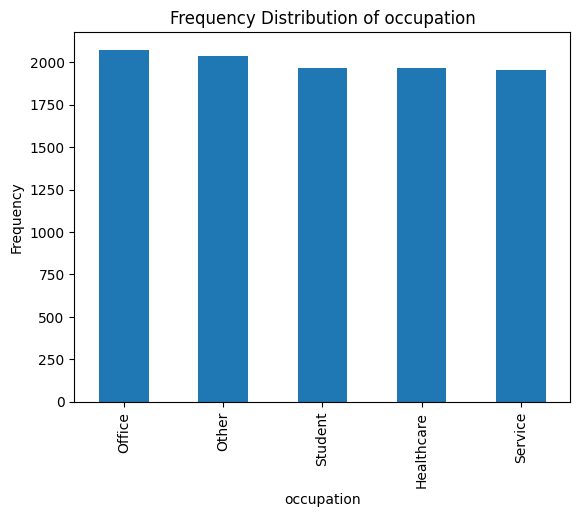

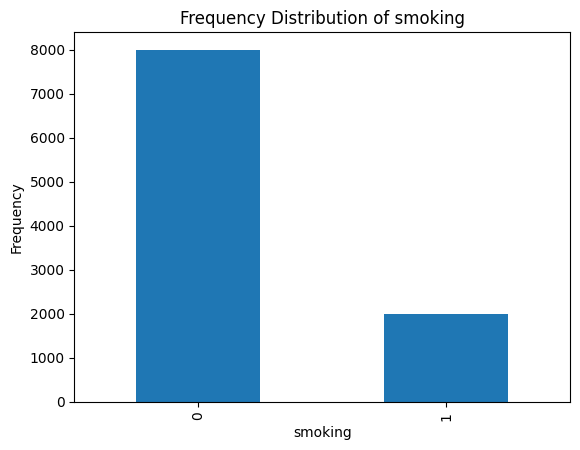

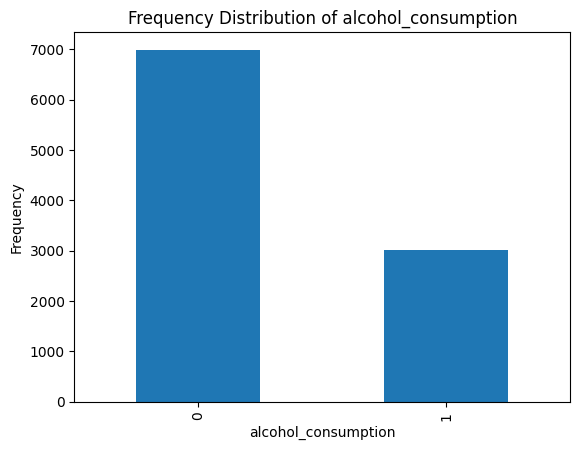

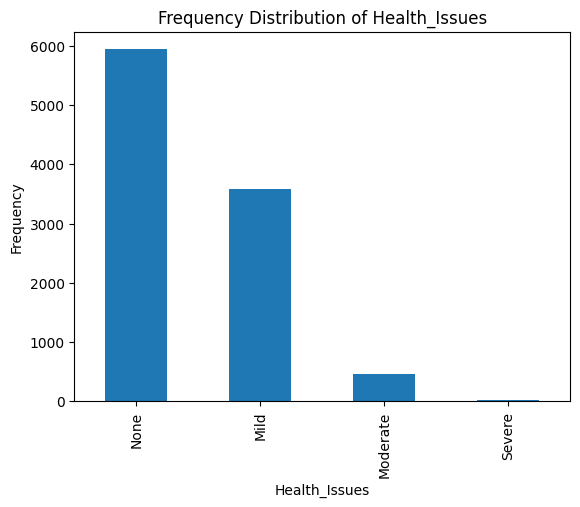

In [47]:
col_names = ['age', 'gender', 'country', 'daily_coffee_intake', 'caffeine_lavel_mg', 'sleep_duration_hrs','sleep_quality', 'BMI', 'heart_rate', 'stress_level', 'physical_activity', 'occupation', 'smoking','alcohol_consumption','Health_Issues']
for col in col_names:
  df[col].value_counts().plot(kind='bar')
  plt.title(f"Frequency Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

### Explore `Health_Issues` variable

---



In [48]:
df['Health_Issues'].value_counts()

,count
Health_Issues,
None,5941
Mild,3579
Moderate,463
Severe,17


The `Health_Issues` target variable is Nominal in nature.

### Missing values in variables

In [49]:
# check missing values in variables

df.isnull().sum()

,0
age,0
gender,0
country,0
daily_coffee_intake,0
caffeine_lavel_mg,0
sleep_duration_hrs,0
sleep_quality,0
BMI,0
heart_rate,0
stress_level,0


Tidak ada missing value di datasetnya

### Encode categorical variables


Now, I will encode the categorical variables.

In [50]:
for column in ['age', 'gender', 'country', 'daily_coffee_intake', 'caffeine_lavel_mg', 'sleep_duration_hrs','sleep_quality', 'BMI', 'heart_rate', 'stress_level', 'physical_activity', 'occupation', 'smoking','alcohol_consumption']:
  print(df[column].unique())

[40 33 42 53 32 44 29 41 37 18 28 22 38 24 52 35 36 21 39 27 31 57 34 20
 19 43 26 47 30 46 51 25 45 64 48 61 23 50 67 80 62 60 56 54 49 59 58 71
 55 65 66 63 73 72 68 70 69 77 75]
['Male' 'Female' 'Other']
['Germany' 'Brazil' 'Spain' 'Mexico' 'France' 'Canada' 'UK' 'Switzerland'
 'Netherlands' 'Italy' 'China' 'Japan' 'Belgium' 'Finland' 'Australia'
 'USA' 'Sweden' 'India' 'Norway' 'South Korea']
[3.5 1.  5.3 2.6 3.1 3.4 2.7 4.5 1.7 4.  4.1 4.7 1.4 3.2 4.3 0.7 2.2 0.
 2.4 4.6 0.4 1.9 0.8 2.5 1.5 2.8 4.4 3.8 2.  3.3 2.1 3.6 1.6 1.1 0.9 4.9
 0.1 5.4 1.3 0.6 1.8 2.9 4.2 2.3 3.9 1.2 7.6 0.2 7.1 5.2 0.5 3.7 5.  6.2
 3.  4.8 5.1 7.3 5.8 5.9 6.1 5.5 5.7 6.4 0.3 5.6 6.7 6.  6.5 6.3 8.2 7.2
 7.  6.6 7.8 6.8 7.7 6.9]
[328.1  94.1 503.7 ... 460.2 509.1  59.1]
[ 7.5  6.2  5.9  7.3  5.3  6.4  7.8  5.5  7.1  8.1  6.5  6.9  6.6  6.8
  7.7  5.7  5.   6.1  6.   8.3  9.2  7.9  4.8  7.4  7.   7.2  5.8  9.4
  7.6  8.   5.4  8.2  6.3  4.5  9.6  5.2  4.7  4.6  8.7  4.9  9.8  6.7
  5.6  8.8  4.2  8.5 10.   8

In [51]:
# Encoding for ordinal column
gender_map = {'Male': 1, 'Female': 2, 'Other': 3}
country_map = {
 'Australia': 1,
 'Belgium': 2,
 'Brazil': 3,
 'Canada': 4,
 'China': 5,
 'Finland': 6,
 'France': 7,
 'Germany': 8,
 'India': 9,
 'Italy': 10,
 'Japan': 11,
 'Mexico': 12,
 'Netherlands': 13,
 'Norway': 14,
 'South Korea': 15,
 'Spain': 16,
 'Sweden': 17,
 'Switzerland': 18,
 'UK': 19,
 'USA': 20
}
sleep_quality_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
stress_level_map = {'Low': 1, 'Medium': 2, 'High': 3}
occupation_map = {
 'Healthcare': 1,
 'Office': 2,
 'Other': 3,
 'Service': 4,
 'Student': 5
}
health_issues_map = {
 'Mild': 1,
 'Moderate': 2,
 'None': 3,
 'Severe': 4
}

df['gender'] = df['gender'].map(gender_map)
df['country'] = df['country'].map(country_map)
df['sleep_quality'] = df['sleep_quality'].map(sleep_quality_map)
df['stress_level'] = df['stress_level'].map(stress_level_map)
df['occupation'] = df['occupation'].map(occupation_map)
df['Health_Issues'] = df['Health_Issues'].map(health_issues_map)

df.sample(n = 5)

,age,gender,country,daily_coffee_intake,caffeine_lavel_mg,sleep_duration_hrs,sleep_quality,BMI,heart_rate,stress_level,physical_activity,occupation,smoking,alcohol_consumption,Health_Issues
6118,41,1,11,5.0,473.0,6.2,3,23.6,73,1,12.6,5,0,0,3
310,32,1,19,2.8,263.1,6.9,3,26.6,85,1,5.2,3,0,0,3
4837,25,2,9,2.2,210.9,5.4,2,25.3,61,2,14.3,3,0,1,1
5413,45,1,10,0.8,76.8,5.2,2,26.3,81,2,2.5,2,0,0,1
4846,18,2,10,2.2,204.4,5.9,2,21.8,71,2,8.5,2,0,0,1


# **Declare feature vector and target variable** <a class="anchor" id="10"></a>


In [52]:
X = df.drop(['Health_Issues'], axis=1)

y = df['Health_Issues']

In [53]:
X.head()

,age,gender,country,daily_coffee_intake,caffeine_lavel_mg,sleep_duration_hrs,sleep_quality,BMI,heart_rate,stress_level,physical_activity,occupation,smoking,alcohol_consumption
0,40,1,8,3.5,328.1,7.5,3,24.9,78,1,14.5,3,0,0
1,33,1,8,1.0,94.1,6.2,3,20.0,67,1,11.0,4,0,0
2,42,1,3,5.3,503.7,5.9,2,22.7,59,2,11.2,2,0,0
3,53,1,8,2.6,249.2,7.3,3,24.7,71,1,6.6,3,0,0
4,32,2,16,3.1,298.0,5.3,2,24.1,76,2,8.5,5,0,1


In [54]:
y.head()

,Health_Issues
0,3
1,3
2,1
3,1
4,1


# **Split data into separate training and test set** <a class="anchor" id="11"></a>

In [55]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [56]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((8000, 14), (2000, 14))

In [57]:
X_train.head()

,age,gender,country,daily_coffee_intake,caffeine_lavel_mg,sleep_duration_hrs,sleep_quality,BMI,heart_rate,stress_level,physical_activity,occupation,smoking,alcohol_consumption
9254,37,1,16,4.3,405.6,5.4,2,18.0,86,2,2.4,4,0,1
1561,26,1,9,0.0,0.0,5.5,2,28.3,75,2,10.8,3,0,0
1670,32,1,15,2.8,268.1,7.3,3,27.4,69,1,8.6,2,0,0
6087,18,1,15,2.2,208.6,8.1,4,16.3,83,1,8.9,3,0,1
6669,43,2,19,2.6,251.1,9.4,4,25.4,68,1,3.4,2,0,0


In [58]:
X_test.head()

,age,gender,country,daily_coffee_intake,caffeine_lavel_mg,sleep_duration_hrs,sleep_quality,BMI,heart_rate,stress_level,physical_activity,occupation,smoking,alcohol_consumption
6252,66,1,14,2.6,245.9,6.7,3,30.1,76,1,1.9,4,0,1
4684,22,2,12,3.1,293.1,7.6,3,20.4,69,1,5.0,4,0,0
1731,30,1,1,3.9,372.4,6.4,3,27.5,75,1,13.8,2,0,0
4742,35,1,8,1.0,92.5,5.3,2,23.1,71,2,2.4,4,0,0
4521,47,1,10,1.3,119.0,6.9,3,28.4,64,1,9.6,2,1,0


We now have training and test set ready for model building.

# **Decision Tree Classifier with criterion gini index** <a class="anchor" id="13"></a>


In [59]:
# import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

In [60]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=0)

clf_gini.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=0)

### Predict the Test set results with criterion gini index

In [61]:
y_pred_gini = clf_gini.predict(X_test)

### Check accuracy score with criterion gini index

In [62]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.9965


Here, **y_test** are the true class labels and **y_pred_gini** are the predicted class labels in the test-set.

### Visualize decision-trees

[Text(0.5, 0.9, 'x[6] <= 2.5\ngini = 0.519\nsamples = 8000\nvalue = [2885, 380, 4723, 12]'),
 Text(0.25, 0.7, 'x[0] <= 50.5\ngini = 0.253\nsamples = 2446\nvalue = [2085, 349, 0, 12]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[7] <= 29.95\ngini = 0.118\nsamples = 2225\nvalue = [2085, 140, 0, 0]'),
 Text(0.0625, 0.3, 'gini = 0.0\nsamples = 2079\nvalue = [2079, 0, 0, 0]'),
 Text(0.1875, 0.3, 'x[7] <= 30.05\ngini = 0.079\nsamples = 146\nvalue = [6, 140, 0, 0]'),
 Text(0.125, 0.1, 'gini = 0.49\nsamples = 14\nvalue = [6, 8, 0, 0]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 132\nvalue = [0, 132, 0, 0]'),
 Text(0.375, 0.5, 'x[7] <= 30.0\ngini = 0.103\nsamples = 221\nvalue = [0, 209, 0, 12]'),
 Text(0.3125, 0.3, 'gini = 0.0\nsamples = 209\nvalue = [0, 209, 0, 0]'),
 Text(0.4375, 0.3, 'gini = 0.0\nsamples = 12\nvalue = [0, 0, 0, 12]'),
 Text(0.75, 0.7, 'x[0] <= 50.5\ngini = 0.256\nsamples = 5554\nvalue = [800, 31, 4723, 0]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'x[7] <= 29.95

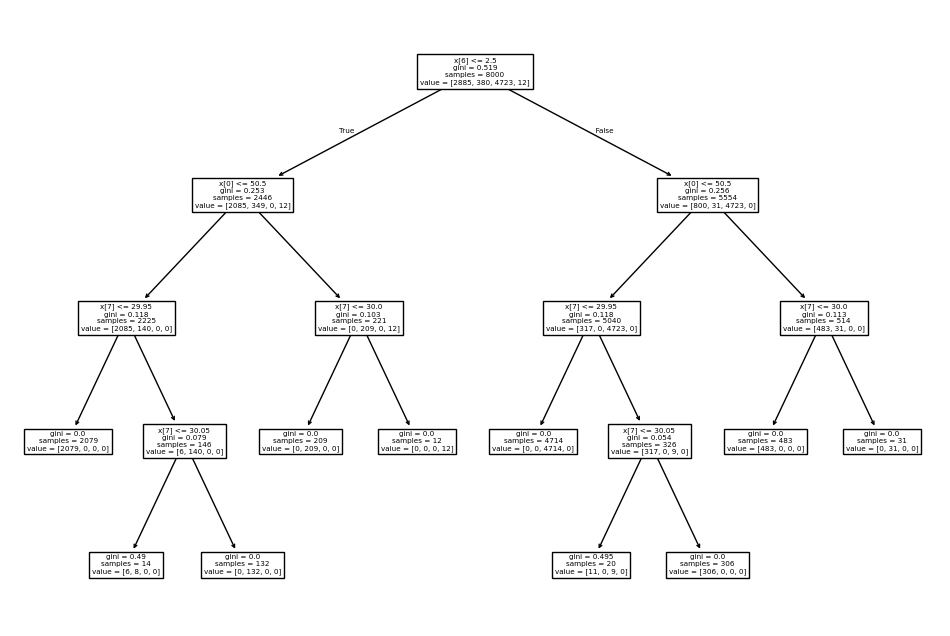

In [63]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_gini.fit(X_train, y_train))

# **Decision Tree Classifier with criterion entropy** <a class="anchor" id="14"></a>


In [64]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

clf_en.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

### Predict the Test set results with criterion entropy

In [65]:
y_pred_en = clf_en.predict(X_test)

### Check accuracy score with criterion entropy

In [66]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.9965


### Visualize decision-trees

[Text(0.5, 0.875, 'x[6] <= 2.5\nentropy = 1.202\nsamples = 8000\nvalue = [2885, 380, 4723, 12]'),
 Text(0.25, 0.625, 'x[0] <= 50.5\nentropy = 0.635\nsamples = 2446\nvalue = [2085, 349, 0, 12]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[7] <= 29.95\nentropy = 0.339\nsamples = 2225\nvalue = [2085, 140, 0, 0]'),
 Text(0.0625, 0.125, 'entropy = 0.0\nsamples = 2079\nvalue = [2079, 0, 0, 0]'),
 Text(0.1875, 0.125, 'entropy = 0.247\nsamples = 146\nvalue = [6, 140, 0, 0]'),
 Text(0.375, 0.375, 'x[7] <= 30.0\nentropy = 0.304\nsamples = 221\nvalue = [0, 209, 0, 12]'),
 Text(0.3125, 0.125, 'entropy = 0.0\nsamples = 209\nvalue = [0, 209, 0, 0]'),
 Text(0.4375, 0.125, 'entropy = 0.0\nsamples = 12\nvalue = [0, 0, 0, 12]'),
 Text(0.75, 0.625, 'x[0] <= 50.5\nentropy = 0.643\nsamples = 5554\nvalue = [800, 31, 4723, 0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[7] <= 29.95\nentropy = 0.339\nsamples = 5040\nvalue = [317, 0, 4723, 0]'),
 Text(0.5625, 0.125, 'entropy = 0.0\nsample

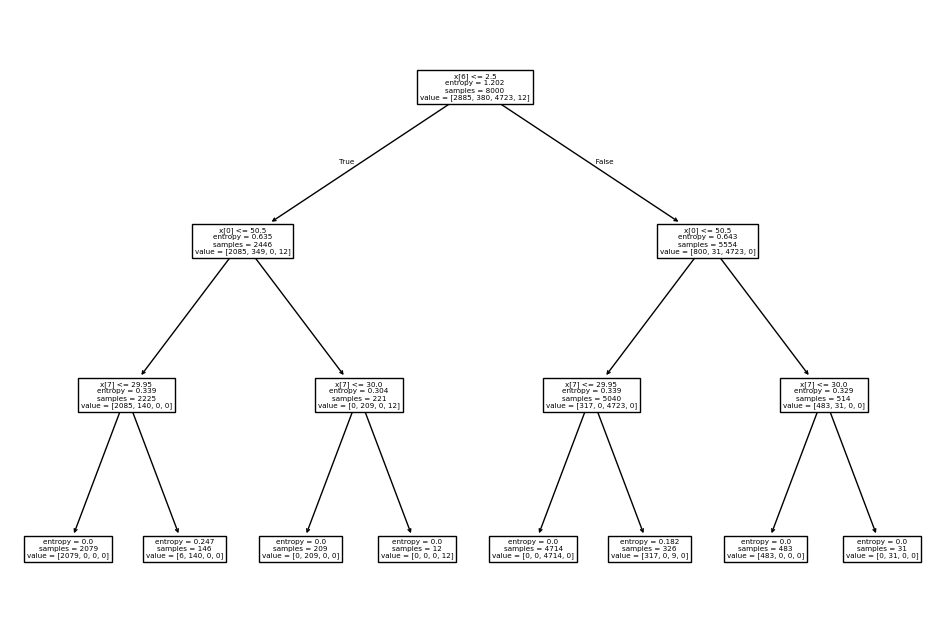

In [67]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_en.fit(X_train, y_train))

# **Naive Bayes** <a class="anchor" id="16"></a>

In [68]:
from sklearn.naive_bayes import GaussianNB

nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

GaussianNB()

In [69]:
y_pred_nb = nb_classifier.predict(X_test)

### Check accuracy score with naive bayes

In [70]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with naive bayes: {0:0.4f}'. format(accuracy_score(y_test, y_pred_nb)))

Model accuracy score with naive bayes: 0.8575


# **Classification Report** <a class="anchor" id="16"></a>



**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model. I have described these terms in later.

We can print a classification report as follows:-

In [71]:
# DECISION TREE ENTROPY
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           1       0.99      1.00      0.99       694
           2       0.99      0.99      0.99        83
           3       1.00      1.00      1.00      1218
           4       1.00      1.00      1.00         5

    accuracy                           1.00      2000
   macro avg       0.99      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [72]:
# DECISION TREE GINI
print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

           1       0.99      1.00      0.99       694
           2       0.99      0.99      0.99        83
           3       1.00      1.00      1.00      1218
           4       1.00      1.00      1.00         5

    accuracy                           1.00      2000
   macro avg       0.99      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [73]:
# DECISION TREE NAIVE BAYES
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           1       0.88      0.70      0.78       694
           2       0.75      0.14      0.24        83
           3       0.85      1.00      0.92      1218
           4       0.00      0.00      0.00         5

    accuracy                           0.86      2000
   macro avg       0.62      0.46      0.49      2000
weighted avg       0.85      0.86      0.84      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
# Make a prediction with the gini index model

# Input values: age 28, gender Male, country Brazil, daily_coffee_intake 3, caffeine_level_mg 280, sleep_duration_hrs 5, sleep_quality Poor, BMI 25.4, heart_Rate 85, stress_level High, physical_activity 2, smoking 1, alcohol_consumption 1
# These values need to be encoded according to the maps created earlier
input_data = {
    'age': 28,
    'gender': gender_map['Male'],
    'country': country_map['Brazil'],
    'occupation': occupation_map['Student'],
    'daily_coffee_intake': 3,
    'caffeine_lavel_mg': 280,
    'sleep_duration_hrs': 5,
    'sleep_quality': sleep_quality_map['Poor'],
    'BMI': 25.4,
    'heart_Rate': 85,
    'stress_level': stress_level_map['High'],
    'physical_activity': 2,
    'smoking': 1,
    'alcohol_consumption': 1
}

# Convert the input data to a pandas DataFrame
input_df = pd.DataFrame([input_data])

# Reindex columns to match the training data
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Make the prediction using the gini model
prediction_gini = clf_gini.predict(input_df)


# To get the inverse, we can use the inverse_prediction_map to get the original label
# Redefine inverse_prediction_map
inverse_prediction_map = {v: k for k, v in health_issues_map.items()}

print(f"The predicted class for the given input using the gini index model is: {inverse_prediction_map[int(prediction_gini[0])]}")

The predicted class for the given input using the gini index model is: Mild


In [75]:
# Make a prediction with the entropy model

# Input values: age 28, gender Male, country Brazil, daily_coffee_intake 3, caffeine_level_mg 280, sleep_duration_hrs 5, sleep_quality Poor, BMI 25.4, heart_Rate 85, stress_level High, physical_activity 2, smoking 1, alcohol_consumption 1
# These values need to be encoded according to the maps created earlier
input_data = {
    'age': 28,
    'gender': gender_map['Male'],
    'country': country_map['Brazil'],
    'occupation': occupation_map['Student'],
    'daily_coffee_intake': 3,
    'caffeine_lavel_mg': 280,
    'sleep_duration_hrs': 5,
    'sleep_quality': sleep_quality_map['Poor'],
    'BMI': 25.4,
    'heart_Rate': 85,
    'stress_level': stress_level_map['High'],
    'physical_activity': 2,
    'smoking': 1,
    'alcohol_consumption': 1
}

# Convert the input data to a pandas DataFrame
input_df = pd.DataFrame([input_data])

# Reindex columns to match the training data
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Make the prediction using the entropy model
prediction_en = clf_en.predict(input_df)

# To get the inverse, we can use the inverse_prediction_map to get the original label
# Redefine inverse_prediction_map (although it should be available from previous cells)
inverse_prediction_map = {v: k for k, v in health_issues_map.items()}

print(f"The predicted class for the given input using the entropy model is: {inverse_prediction_map[int(prediction_en[0])]}")

The predicted class for the given input using the entropy model is: Mild


In [76]:
# Make a prediction with the Naive Bayes model

# Input values: age 28, gender Male, country Brazil, daily_coffee_intake 3, caffeine_level_mg 280, sleep_duration_hrs 5, sleep_quality Poor, BMI 25.4, heart_Rate 85, stress_level High, physical_activity 2, smoking 1, alcohol_consumption 1
# These values need to be encoded according to the maps created earlier
input_data = {
    'age': 28,
    'gender': gender_map['Male'],
    'country': country_map['Brazil'],
    'occupation': occupation_map['Student'],
    'daily_coffee_intake': 3,
    'caffeine_lavel_mg': 280,
    'sleep_duration_hrs': 5,
    'sleep_quality': sleep_quality_map['Poor'],
    'BMI': 25.4,
    'heart_Rate': 85,
    'stress_level': stress_level_map['High'],
    'physical_activity': 2,
    'smoking': 1,
    'alcohol_consumption': 1
}

# Convert the input data to a pandas DataFrame
input_df = pd.DataFrame([input_data])

# Reindex columns to match the training data
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Make the prediction using the Naive Bayes model
prediction_nb = nb_classifier.predict(input_df)

# To get the inverse, we can use the inverse_prediction_map to get the original label
# Redefine inverse_prediction_map (although it should be available from previous cells)
inverse_prediction_map = {v: k for k, v in health_issues_map.items()}

print(f"The predicted class for the given input using the Naive Bayes model is: {inverse_prediction_map[int(prediction_nb[0])]}")

The predicted class for the given input using the Naive Bayes model is: Moderate
